In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/retail_features.csv')

In [4]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  int64  
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
 8   Revenue      397884 non-null  float64
 9   Year         397884 non-null  int64  
 10  Month        397884 non-null  int64  
 11  MonthName    397884 non-null  object 
 12  Day          397884 non-null  int64  
 13  Hour         397884 non-null  int64  
 14  Weekday      397884 non-null  object 
dtypes: float64(3), int64(6), object(6)
memory usage: 45.5+ MB


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0
Year,0


In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [6]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [7]:
rfm.columns = ['Recency','Frequency','Monetary']

In [8]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


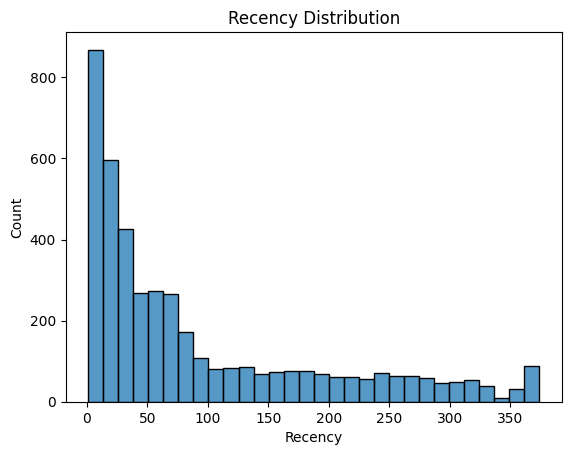

In [9]:
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency Distribution')
plt.show()

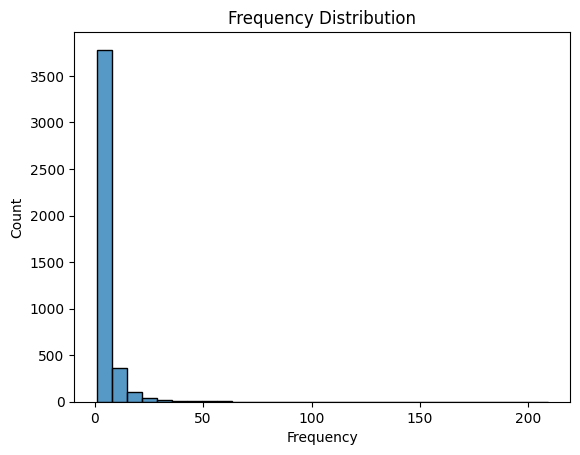

In [10]:
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')
plt.show()

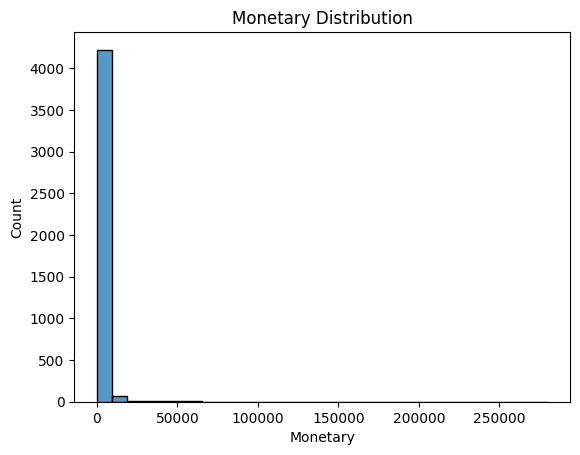

In [11]:
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')
plt.show()

In [12]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

In [13]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [14]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [15]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [16]:
def segment_customer(row):

    if row['RFM_Score'] == '555':
        return 'Champions'

    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'

    elif row['R_Score'] >= 4:
        return 'Potential Loyalist'

    elif row['R_Score'] <= 2:
        return 'At Risk'

    else:
        return 'Others'

In [17]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [18]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,1708
Others,858
Loyal Customers,791
Potential Loyalist,633
Champions,348


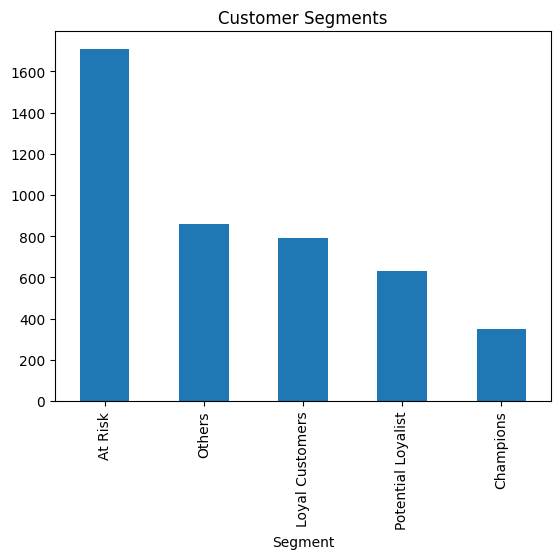

In [19]:
rfm['Segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segments')
plt.show()

In [20]:
rfm.reset_index(inplace=True)
rfm.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/rfm_customer_segments.csv',
    index=False
)